In [3]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

class BertTextEncoder(nn.Module):
    def __init__(self, model_name="cl-tohoku/bert-base-japanese-whole-word-masking", 
                 output_embedding_dim=None, freeze_bert=True):
        """
        BERTを用いたテキストエンコーダ。

        Args:
            model_name (str): 使用するHugging Faceの事前学習済みモデル名。
            output_embedding_dim (int, optional): 
                BERTの出力特徴量をこの次元に射影するための全結合層の出力次元。
                Noneの場合、BERTの生の出力特徴量（通常768次元）をそのまま利用します。
            freeze_bert (bool): Trueの場合、BERTの重みを凍結してファインチューニングしません。
        """
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.bert_model = AutoModel.from_pretrained(model_name)
        
        self.bert_output_dim = self.bert_model.config.hidden_size # 通常は768

        if freeze_bert:
            for param in self.bert_model.parameters():
                param.requires_grad = False
        
        # オプション: BERTの出力をさらに指定次元に射影する全結合層
        if output_embedding_dim and output_embedding_dim != self.bert_output_dim:
            self.projection_layer = nn.Linear(self.bert_output_dim, output_embedding_dim)
        else:
            self.projection_layer = nn.Identity() # 射影しない場合はそのまま出力

    def forward(self, texts):
        """
        テキストのリストを受け取り、埋め込みベクトルのバッチを返します。

        Args:
            texts (list of str): エンコードするテキストのリスト (バッチ)。例: ["コメント1", "コメント2", ...]

        Returns:
            torch.Tensor: テキスト埋め込みのバッチ。形状は (batch_size, embedding_dim)。
                         embedding_dim は output_embedding_dim を指定した場合はその値、
                         指定しない場合はBERTの出力次元 (例: 768)。
        """
        # トークナイズ処理
        # padding=True: バッチ内で最長のシーケンスに合わせてパディング
        # truncation=True: モデルの最大長を超える場合は切り捨て
        # return_tensors='pt': PyTorchテンソルで結果を返す
        # device=self.bert_model.device: モデルと同じデバイスにテンソルを作成
        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            return_tensors='pt',
            max_length=self.tokenizer.model_max_length # モデルが扱える最大長 (通常512)
        ).to(self.bert_model.device)

        # BERTモデルによるエンコード
        # attention_maskも自動的に渡される
        outputs = self.bert_model(**inputs)

        # BERTの出力からテキスト全体の埋め込みベクトルを取得
        # 一般的には[CLS]トークンの隠れ状態 (outputs.last_hidden_state[:, 0, :]) を使用する
        # または、全トークンの隠れ状態の平均プーリング (outputs.last_hidden_state.mean(dim=1)) も考えられる
        # ここでは[CLS]トークン表現を使用
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # (batch_size, bert_output_dim)
        
        # オプションの射影層を適用
        projected_embedding = self.projection_layer(cls_embedding) # (batch_size, output_embedding_dim or bert_output_dim)
        
        return projected_embedding

In [4]:
# ---- 使用例 ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. BERTの生の出力をそのまま使う場合
text_encoder_raw = BertTextEncoder(
    model_name="cl-tohoku/bert-base-japanese-whole-word-masking",
    freeze_bert=True # 学習初期は凍結することが多い
).to(device)

# 2. BERTの出力を256次元に射影する場合 (対照学習で次元を揃えるためなど)
# この256という値は、局面エンコーダ側の出力次元や、対照学習で用いたい共通の埋め込み次元に合わせます。
projection_dim = 256 
text_encoder_projected = BertTextEncoder(
    model_name="cl-tohoku/bert-base-japanese-whole-word-masking",
    output_embedding_dim=projection_dim,
    freeze_bert=False # BERTもファインチューニングする場合
).to(device)

# ダミーの棋譜コメント
sample_comments = [
    "▲２六歩 △３四歩 ▲７六歩 △８四歩",
    "ここで▲２二角成と踏み込むのが好手でした。",
    "先手優勢。次の▲５五角が厳しい一手。",
    "難解な中盤戦が続いています。"
]

# エンコード実行 (生の出力)
text_encoder_raw.eval() # 評価モード
with torch.no_grad():
    embeddings_raw = text_encoder_raw(sample_comments)
print("BERT Raw Embeddings shape:", embeddings_raw.shape) # (batch_size, 768)

# エンコード実行 (射影後の出力)
text_encoder_projected.train() # 学習モード (Dropoutなどが有効になる場合)
# 実際には勾配計算が必要な場合は torch.no_grad() を外す
with torch.no_grad(): # ここでは例として勾配計算なし
    embeddings_projected = text_encoder_projected(sample_comments)
print("Projected Embeddings shape:", embeddings_projected.shape) # (batch_size, 256)

# --- トークナイザの動作確認 (参考) ---
tokenizer_check = AutoTokenizer.from_pretrained("cl-tohoku/bert-base-japanese-whole-word-masking")
sample_text = "▲２六歩 △３四歩"
tokenized_output = tokenizer_check(sample_text, padding=True, truncation=True, return_tensors='pt')
print("\nTokenized output for:", sample_text)
print("Input IDs:", tokenized_output['input_ids'])
print("Decoded tokens:", tokenizer_check.convert_ids_to_tokens(tokenized_output['input_ids'][0]))
print("Attention Mask:", tokenized_output['attention_mask'])

Some weights of the model checkpoint at cl-tohoku/bert-base-japanese-whole-word-masking were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of the model checkpoint at cl-tohoku/bert-base-japanese-whole-word-masking were not used when initializing BertM

BERT Raw Embeddings shape: torch.Size([4, 768])
Projected Embeddings shape: torch.Size([4, 256])

Tokenized output for: ▲２六歩 △３四歩
Input IDs: tensor([[    2, 21033,    25,  1688,  1513, 16196,    48,   755,  1513,     3]])
Decoded tokens: ['[CLS]', '▲', '2', '六', '歩', '△', '3', '四', '歩', '[SEP]']
Attention Mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [2]:
from dlshogi.network.policy_value_network import policy_value_network
from dlshogi import serializers
from dlshogi.common import MAX_MOVE_LABEL_NUM
class dlshogiEncoder(nn.Module):
    def __init__(self, dim_embedding: int, arg_network: str, arg_model: str):
        super().__init__()

        # dlshogiのpolicy networkとvalue networkの出力層前までのネットワークをバックボーンネットワークとする
        model = policy_value_network(arg_network)
        serializers.load_npz(arg_model, model)
        self.backbone = model

        # u21 の出力チャネル数 (k=192)
        self.dlshogi_feature_dim = 192 # k

        # GAP後の特徴量をさらに射影する層
        self.projection = nn.Linear(self.dlshogi_feature_dim, dim_embedding)

    '''
    エンコーダの順伝播
    features1: 入力1, [バッチサイズ, チャネル数(62), 高さ(9), 幅(9)]
    features2: 入力2, [バッチサイズ, チャネル数(57), 高さ(9), 幅(9)]
    '''
    def forward(self, features1: torch.Tensor, features2: torch.Tensor):
        with torch.no_grad():
            _, _, _, _, resnet_features = self.backbone(features1, features2)

        # Global Average Pooling
        pooled_features = F.adaptive_avg_pool2d(resnet_features, (1, 1)) # (batch, 192, 1, 1)
        board_features_raw = torch.flatten(pooled_features, 1) # (batch, 192)

        # 最終的な埋め込みベクトルに射影
        final_board_embedding = self.projection(board_features_raw) # (batch, projection_dim)
        
        return final_board_embedding

In [4]:
# gemimi提案エンコーダ
class dlshogiEncoder(nn.Module):
    def __init__(self, dim_embedding: int, arg_network: str, arg_model: str, freeze_backbone: bool = True): # freeze_backboneフラグを追加
        super().__init__()
        model = policy_value_network(arg_network)
        serializers.load_npz(arg_model, model)
        self.backbone = model

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.freeze_backbone_in_forward = freeze_backbone # forwardでも使うかどうかのフラグ

        self.dlshogi_feature_dim = 192
        self.projection = nn.Linear(self.dlshogi_feature_dim, dim_embedding)

    def forward(self, features1: torch.Tensor, features2: torch.Tensor):
        # self.freeze_backbone_in_forward が True の場合、または __init__ で requires_grad=False にした場合
        # ここでの torch.no_grad() は、主に requires_grad=True だが一時的に勾配計算を止めたい場合に効果的
        # __init__ で requires_grad=False に設定済みなら、ここでの no_grad() は必須ではないが、
        # 念のためや、他の部分で requires_grad が True に変更される可能性を考慮するなら残しても良い
        if self.freeze_backbone_in_forward: # もし __init__ で requires_grad=False にしないならこのif文は必須
            with torch.no_grad():
                # 5番目の戻り値がu21であると仮定
                outputs = self.backbone(features1, features2) 
                resnet_features = outputs[4] # インデックスでアクセスする方が安全か
        else:
            outputs = self.backbone(features1, features2)
            resnet_features = outputs[4]

        pooled_features = F.adaptive_avg_pool2d(resnet_features, (1, 1))
        board_features_raw = torch.flatten(pooled_features, 1)
        final_board_embedding = self.projection(board_features_raw)
        return final_board_embedding

In [ ]:
shogi_dataset = ShogiClipDataset(
    hcpe_file_paths=["path/to/your/data.hcpe"], 
    comment_csv_file_path="path/to/your/comments.csv",
    csv_index_col_name='index_column_name_in_csv', # 例: 'ID' や 'CommentIndex'
    csv_comment_col_name='comment_text_column_name_in_csv' # 例: 'Text' や 'KifuComment'
)

In [5]:
import os
import numpy as np
import logging
import torch
from torch.utils.data import Dataset # DataLoaderはここでは直接使わない
from cshogi import Board
from cshogi.dlshogi import make_input_features, FEATURES1_NUM, FEATURES2_NUM

# --- ユーザー提供のdtype定義 ---
dtypeHcp = np.dtype((np.uint8, 32))
dtypeEval = np.dtype(np.int16)
dtypeMove16 = np.dtype(np.int16)
dtypeGameResult = np.dtype(np.int8)

HuffmanCodedPosAndEvalComment = np.dtype(
    [('hcp', dtypeHcp),
     ('eval', dtypeEval),
     ('bestMove16', dtypeMove16),
     ('gameResult', dtypeGameResult),
     ('dummy', np.uint8),
     ('comment_index', np.int32),
    ])
# -----------------------------------

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class ShogiClipDataset(Dataset):
    def __init__(self, hcpe_file_paths, comment_csv_file_path, preload_hcpe=True,
                 csv_index_col_name='index', csv_comment_col_name='comment'):
        super().__init__()

        if isinstance(hcpe_file_paths, str):
            hcpe_file_paths = [hcpe_file_paths]
        
        self.hcpe_data = self._load_hcpe_data(hcpe_file_paths, preload_hcpe) # 常にNumPy配列を返すようにする
        self.comments_dict = self._load_comments_from_csv(
            comment_csv_file_path, 
            csv_index_col_name, 
            csv_comment_col_name
        )
        
        # hcpe_dataがNumPy配列であることを前提とし、そのサイズで空かどうかを判定
        if self.hcpe_data.size == 0: # <--- エラー箇所を修正
            logging.warning("HCPEデータがロードされませんでした（または空です）。データセットは空になります。")
        
        if not self.comments_dict: # comments_dictはPython辞書なので `not` でのチェックでOK
            logging.warning("コメントデータがロードされませんでした（または空です）。")

    def _load_hcpe_data(self, file_paths, preload):
        if not preload:
            raise NotImplementedError("遅延ロードは現在実装されていません。preload_hcpe=Trueを使用してください。")

        all_hcpe_records = []
        for path in file_paths:
            if os.path.exists(path):
                logging.info(f"HCPEデータをロード中: {path}")
                try:
                    data = np.fromfile(path, dtype=HuffmanCodedPosAndEvalComment)
                    if data.size > 0: # データが実際に存在する場合のみ追加
                        all_hcpe_records.append(data)
                except Exception as e:
                    logging.error(f"HCPEファイルのロードに失敗しました: {path} - {e}")
            else:
                logging.warning(f"HCPEファイルが見つかりません: {path}")
        
        if not all_hcpe_records:
            # データがない場合は、正しいdtypeを持つ空のNumPy配列を返す
            return np.array([], dtype=HuffmanCodedPosAndEvalComment) 
        return np.concatenate(all_hcpe_records)

    def _load_comments_from_csv(self, csv_file_path, index_col_name, comment_col_name):
        # (このメソッドは前回の回答と同じで問題ありません)
        comments_map = {}
        if os.path.exists(csv_file_path):
            logging.info(f"コメントデータをCSVからロード中: {csv_file_path}")
            try:
                with open(csv_file_path, 'r', encoding='utf-8', newline='') as csvfile:
                    reader = csv.DictReader(csvfile)
                    if index_col_name not in reader.fieldnames or \
                       comment_col_name not in reader.fieldnames:
                        logging.error(f"CSVファイルに必要な列が見つかりません: '{index_col_name}', '{comment_col_name}'")
                        return {}
                        
                    for row in reader:
                        try:
                            idx = int(row[index_col_name])
                            comment_text = row[comment_col_name]
                            comments_map[idx] = comment_text.strip()
                        except ValueError:
                            logging.warning(f"CSVの行でインデックスを整数に変換できませんでした: {row}")
                        except KeyError:
                             logging.warning(f"CSVの行で指定された列名が見つかりませんでした: {row}")
                logging.info(f"{len(comments_map)} 件のコメントをCSVからロードしました。")
            except Exception as e:
                logging.error(f"コメントCSVファイルのロード/解析に失敗しました: {csv_file_path} - {e}")
        else:
            logging.warning(f"コメントCSVファイルが見つかりません: {csv_file_path}")
        return comments_map

    def __len__(self):
        # hcpe_dataが常にNumPy配列なので、.size または len() で要素数を取得できる
        return self.hcpe_data.shape[0] if self.hcpe_data.ndim > 0 else 0


    def __getitem__(self, idx):
        # __len__ の修正に伴い、ここでのチェックも調整可能だが、
        # len(self.hcpe_data) はNumPy配列の最初の次元の長さを返すので、そのままでも機能する
        if idx >= len(self.hcpe_data): 
             raise IndexError(f"インデックス {idx} が範囲外です。hcpe_dataの長さ: {len(self.hcpe_data)}")

        hcpe_record = self.hcpe_data[idx]
        board = Board()
        board.set_hcp(hcpe_record['hcp'])

        features1_sample = np.zeros((FEATURES1_NUM, 9, 9), dtype=np.float32)
        features2_sample = np.zeros((FEATURES2_NUM, 9, 9), dtype=np.float32)
        make_input_features(board, features1_sample, features2_sample)

        comment_idx = hcpe_record['comment_index']
        raw_comment_text = self.comments_dict.get(comment_idx, "")
        
        if not raw_comment_text:
             logging.debug(f"コメントが見つかりません/空です。hcpe_index: {idx}, comment_index_in_hcpe: {comment_idx}")

        return features1_sample, features2_sample, raw_comment_text

# (shogi_clip_collate_fn は変更なしでそのまま利用できます)
def shogi_clip_collate_fn(batch):
    features1_list = [item[0] for item in batch]
    features2_list = [item[1] for item in batch]
    raw_texts_list = [item[2] for item in batch] 

    batched_features1 = torch.from_numpy(np.stack(features1_list))
    batched_features2 = torch.from_numpy(np.stack(features2_list))

    return batched_features1, batched_features2, raw_texts_list

In [16]:
# --- 使用例 ---

# --- DatasetとDataLoaderのインスタンス化 ---
TRAIN_HCPE_FILE = "/workspace/train_202505.hcpe"
COMMENT_CSV_FILE = "/workspace/kif_caption/comments_202505_all.csv"
hcpe_files = [TRAIN_HCPE_FILE]
comment_csv_file = COMMENT_CSV_FILE
batch_size = 2

# Datasetの作成 (CSVの列名を指定可能)
shogi_dataset = ShogiClipDataset(
    hcpe_file_paths=hcpe_files, 
    comment_csv_file_path=comment_csv_file,
    csv_index_col_name='index', # CSVのインデックス列名
    csv_comment_col_name='comment'  # CSVのコメント列名
)

shogi_dataloader = DataLoader(
    shogi_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=shogi_clip_collate_fn,
    num_workers=0,
    pin_memory=True 
)

if len(shogi_dataset) > 0:
    logging.info(f"データローダから {len(shogi_dataloader)} バッチを取得します。")
    for i, (batch_f1, batch_f2, batch_texts) in enumerate(shogi_dataloader):
        logging.info(f"--- バッチ {i+1} ---")
        logging.info(f"batch_f1 shape: {batch_f1.shape}")
        logging.info(f"batch_f2 shape: {batch_f2.shape}")
        logging.info(f"batch_texts (len: {len(batch_texts)}): {batch_texts}")
        if i >= 1: 
            break
else:
    logging.warning("データセットが空のため、データローダのテストをスキップします。")


2025-06-06 04:26:20,415 - INFO - HCPEデータをロード中: /workspace/train_202505.hcpe
2025-06-06 04:26:20,438 - INFO - コメントデータをCSVからロード中: /workspace/kif_caption/comments_202505_all.csv
2025-06-06 04:26:21,177 - INFO - 655119 件のコメントをCSVからロードしました。
2025-06-06 04:26:21,178 - INFO - データローダから 308705 バッチを取得します。
2025-06-06 04:26:21,191 - INFO - --- バッチ 1 ---
2025-06-06 04:26:21,192 - INFO - batch_f1 shape: torch.Size([2, 62, 9, 9])
2025-06-06 04:26:21,192 - INFO - batch_f2 shape: torch.Size([2, 57, 9, 9])
2025-06-06 04:26:21,192 - INFO - batch_texts (len: 2): ['上下の挟撃形となって筋に入ってきた。', '△8二玉ならば、(1)▲4六歩と香を補充した手が▲8三香を見てピッタリ。△8三歩の受けにも構わず▲同銀成△同玉▲8四香で強引に突破できる。また、(2)▲5五角も次に▲5二桂成を狙って厳しい。']
2025-06-06 04:26:21,193 - INFO - --- バッチ 2 ---
2025-06-06 04:26:21,193 - INFO - batch_f1 shape: torch.Size([2, 62, 9, 9])
2025-06-06 04:26:21,193 - INFO - batch_f2 shape: torch.Size([2, 57, 9, 9])
2025-06-06 04:26:21,193 - INFO - batch_texts (len: 2): ['やはり▲3三銀成とはできなかった。', 'ここで後手鎮が駒を投じた。投了以下、先手玉への唯一の寄せである△2五桂打が3六の銀で受けきりの形となっており、

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader # DataLoaderはメインスクリプトで使う
import numpy as np
import logging
import datetime # ログファイル名用
import os # ディレクトリ作成用
from tqdm import tqdm # プログレスバー

# --- 1. 統合モデル (ShogiClipModel) ---
class ShogiClipModel(nn.Module):
    def __init__(self, board_encoder, text_encoder):
        super().__init__()
        self.board_encoder = board_encoder
        self.text_encoder = text_encoder
        # CLIPで提案された温度パラメータの初期化方法
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
        logging.info("ShogiClipModel initialized.")

    def forward(self, board_f1, board_f2, raw_texts_list):
        # 各エンコーダから射影済みの埋め込みを取得
        # board_encoderとtext_encoderは、内部で最終的なprojection_dimへの射影まで行う想定
        board_embeddings = self.board_encoder(board_f1, board_f2)
        text_embeddings = self.text_encoder(raw_texts_list)

        # L2正規化 (特徴ベクトルの長さを1にする)
        board_embeddings_norm = F.normalize(board_embeddings, p=2, dim=-1)
        text_embeddings_norm = F.normalize(text_embeddings, p=2, dim=-1)

        return board_embeddings_norm, text_embeddings_norm, self.logit_scale.exp()

# --- 2. 損失関数 (CLIP-style Contrastive Loss) ---
def contrastive_loss_fn(image_embeddings, text_embeddings, logit_scale):
    # image_embeddings: (batch_size, projection_dim)
    # text_embeddings: (batch_size, projection_dim)
    # logit_scale: 温度パラメータ (スカラー)
    
    # コサイン類似度行列を計算 (正規化済みなので内積がコサイン類似度)
    # (N, D) x (D, N) -> (N, N)
    logits_per_image = logit_scale * image_embeddings @ text_embeddings.t()
    logits_per_text = logits_per_image.t() # 対称性を利用

    batch_size = image_embeddings.shape[0]
    labels = torch.arange(batch_size, device=image_embeddings.device) # 対角成分が正例

    loss_image = F.cross_entropy(logits_per_image, labels)
    loss_text = F.cross_entropy(logits_per_text, labels)
    
    total_loss = (loss_image + loss_text) / 2.0
    return total_loss

# --- 3. 訓練関数 ---
def train_epoch(model, dataloader, optimizer, device, scheduler=None):
    model.train()
    total_loss = 0
    num_batches = 0
    
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for batch_f1, batch_f2, batch_texts in progress_bar:
        batch_f1 = batch_f1.to(device)
        batch_f2 = batch_f2.to(device)
        # batch_texts は文字列のリストなので、デバイス転送は不要 (エンコーダ内部で処理)

        optimizer.zero_grad()
        
        board_embeds, text_embeds, temp = model(batch_f1, batch_f2, batch_texts)
        loss = contrastive_loss_fn(board_embeds, text_embeds, temp)
        
        loss.backward()
        optimizer.step()
        if scheduler:
            scheduler.step() # エポックごとではなくステップごとに更新するスケジューラの場合

        total_loss += loss.item()
        num_batches += 1
        progress_bar.set_postfix(loss=loss.item(), lr=optimizer.param_groups[0]['lr'])

    return total_loss / num_batches

# --- 4. 検証関数 ---
def validate_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    
    progress_bar = tqdm(dataloader, desc="Validating", leave=False)
    with torch.no_grad():
        for batch_f1, batch_f2, batch_texts in progress_bar:
            batch_f1 = batch_f1.to(device)
            batch_f2 = batch_f2.to(device)

            board_embeds, text_embeds, temp = model(batch_f1, batch_f2, batch_texts)
            loss = contrastive_loss_fn(board_embeds, text_embeds, temp)

            total_loss += loss.item()
            num_batches += 1
            progress_bar.set_postfix(loss=loss.item())
            
    return total_loss / num_batches

# --- メインの訓練処理 ---
def main_train(config): # configは設定値を持つオブジェクトや辞書を想定
    device = torch.device(config.device)
    logging.info(f"Using device: {device}")

    projection_dim = config.projection_dim # エンコーダが出力する共通の次元
    # データセットとデータローダの準備
    train_dataset = ShogiClipDataset(hcpe_file_paths=config.train_hcpe_files, 
                                     comment_csv_file_path=config.comment_file)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, 
                              collate_fn=shogi_clip_collate_fn, num_workers=config.num_workers, pin_memory=True)
    
    val_dataset = ShogiClipDataset(hcpe_file_paths=config.val_hcpe_files, 
                                   comment_csv_file_path=config.comment_file)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, 
                            collate_fn=shogi_clip_collate_fn, num_workers=config.num_workers, pin_memory=True)
    
    logging.info("DataLoaders created.")


    # モデルのインスタンス化
    board_enc = dlshogiEncoder(projection_dim, config.dlshogi_arg_network, config.dlshogi_arg_model)
    text_enc = BertTextEncoder(output_embedding_dim=projection_dim, model_name=config.bert_model_name, freeze_bert=config.freeze_bert)
    
    shogi_clip_model = ShogiClipModel(board_enc, text_enc).to(device)
    
    # オプティマイザの準備
    # 学習するパラメータを指定 (ファインチューニングの有無に応じて調整)
    params_to_optimize = []
    # board_encoder の射影層 (例: board_enc.projection.parameters())
    # text_encoder の射影層 (例: text_enc.projection_layer.parameters())
    # logit_scale (shogi_clip_model.logit_scale)
    # 必要であれば、各エンコーダ本体のパラメータも追加
    
    # 例: 全てのパラメータを学習対象とする場合 (最初は射影層とlogit_scaleのみが良いかも)
    params_to_optimize.extend(list(shogi_clip_model.parameters())) 
    
    optimizer = optim.AdamW(params_to_optimize, lr=config.learning_rate, weight_decay=config.weight_decay)
    
    # (オプション) 学習率スケジューラ
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.num_epochs * len(train_loader))

    # 結果保存用ディレクトリ
    save_dir = config.save_directory
    os.makedirs(save_dir, exist_ok=True)
    now_str = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

    best_val_loss = float('inf')

    logging.info("Training started.")
    for epoch in range(config.num_epochs):
        print(f"\n--- Epoch {epoch+1}/{config.num_epochs} ---")
        
        train_loss = train_epoch(shogi_clip_model, train_loader, optimizer, device, scheduler) # scheduler も渡す場合 scheduler=scheduler
        print(f"Epoch {epoch+1} Training Loss: {train_loss:.4f}")
        
        val_loss = validate_epoch(shogi_clip_model, val_loader, device)
        print(f"Epoch {epoch+1} Validation Loss: {val_loss:.4f}")
        
        # (オプション) スケジューラのエポックごとの更新 (コサインアニーリングなど)
        if scheduler and not isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
           scheduler.step() 

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            model_save_path = os.path.join(save_dir, f"shogi_clip_model_best_{now_str}.pth")
            torch.save(shogi_clip_model.state_dict(), model_save_path)
            print(f"Best model saved to {model_save_path} (Val Loss: {best_val_loss:.4f})")
    
    logging.info("Training finished.")

    

In [43]:
class ConfigTrain:
    def __init__(self):
        # --- デバイス設定 ---
        self.device = "cuda" if torch.cuda.is_available() else "cpu" # 自動検出 or "cuda", "cpu" を直接指定

        # --- データ関連 ---
        self.train_hcpe_files = ["/workspace/train_202505.hcpe"] # 訓練用HCPEファイルパスのリスト
        self.val_hcpe_files = ["/workspace/test_202505.hcpe"] # 検証用HCPEファイルパスのリスト
        self.comment_file = "/workspace/kif_caption/comments_202505_all.csv" # コメントCSVファイルのパス (訓練用と検証用で共通と仮定)
                                                          # もし別々なら train_comment_file, val_comment_file のように分ける
        self.batch_size = 64  # バッチサイズ
        self.num_workers = 4  # DataLoaderのワーカー数 (環境に合わせて調整)

        # --- モデル関連 ---
        self.projection_dim = 256  # 局面埋め込みとテキスト埋め込みを射影する共通次元

        # dlshogiEncoder設定
        self.dlshogi_arg_network = "kifcaption" # policy_value_network に渡すネットワークタイプ名 (dlshogiの仕様に合わせる)
        self.dlshogi_arg_model = "/workspace/model/model_resnet10_swish-072_for_caption" # dlshogiの学習済みモデルのパス
        # self.freeze_dlshogi_backbone = True # dlshogiEncoderのバックボーンを凍結するかどうか (dlshogiEncoder側でこのフラグを受け取るようにした場合)

        # BertTextEncoder設定
        self.bert_model_name = "cl-tohoku/bert-base-japanese-whole-word-masking" # 使用するBERTモデル名
        self.freeze_bert = True # BERTの重みを凍結するかどうか (True推奨から開始)

        # --- 訓練関連 ---
        self.num_epochs = 20  # 総エポック数
        self.learning_rate = 1e-4  # 学習率
        self.weight_decay = 0.01 # AdamWのweight_decay

        # --- 保存関連 ---
        self.save_directory = "shogi_clip_results" # モデルやログの保存先ディレクトリ

In [6]:
# 改良訓練コード
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import logging
import datetime
import os
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModel # BertTextEncoderで使用

import csv # ログ保存用にCSVモジュールをインポート
import pandas as pd # ログ読み込み・可視化用にpandas (後述)
import matplotlib.pyplot as plt # ログ可視化用にmatplotlib (後述)

# --- ロガー設定 ---
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# === ユーザーが実装する/既にあるモジュール (このファイルに含めるか、別ファイルからimport) ===

# --- 1. 設定クラス (例) ---
class ConfigTrain:
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.train_hcpe_files = ["/workspace/train_202505.hcpe"] # TODO: 実際のパスに置き換え
        self.val_hcpe_files = ["/workspace/test_202505.hcpe"]    # TODO: 実際のパスに置き換え
        self.comment_file = "/workspace/kif_caption/comments_202505_all.csv"   # TODO: 実際のパスに置き換え
        self.csv_index_col_name = 'index'
        self.csv_comment_col_name = 'comment'
        self.batch_size = 256 # 例
        self.num_workers = 0 # まずは0でテスト (環境に合わせて調整)
        self.projection_dim = 256
        self.dlshogi_arg_network = "kifcaption" # TODO: 実際のdlshogi設定
        self.dlshogi_arg_model = "/workspace/model/model_resnet10_swish-072_for_caption" # TODO: 実際のパス
        self.freeze_dlshogi_backbone = True # dlshogiのバックボーンを凍結するか
        self.dlshogi_backbone_lr = 1e-5     # dlshogiバックボーンの学習率 (ファインチューニング時)
        self.bert_model_name = "cl-tohoku/bert-base-japanese-whole-word-masking"
        self.freeze_bert = True             # BERTのバックボーンを凍結するか
        self.bert_backbone_lr = 1e-5        # BERTバックボーンの学習率 (ファインチューニング時)
        self.head_lr = 0.001                 # 射影層とlogit_scaleの学習率
        self.num_epochs = 40
        self.learning_rate = 0.001           # オプティマイザのデフォルト学習率 (主に射影層に適用)
        self.weight_decay = 0.001
        self.clip_grad_norm = 1.0           # 勾配クリッピングのmax_norm (0なら無効)
        self.save_directory = "/workspace/python-dlshogi2/shogi_clip_results"
        self.scheduler_T_max_is_epochs = False # TrueならT_max=num_epochs, FalseならT_max=total_steps

        self.log_file_name = "training_log.csv" # ログファイル名

# --- 統合モデル (ShogiClipModel) ---
class ShogiClipModel(nn.Module):
    def __init__(self, board_encoder, text_encoder):
        super().__init__()
        self.board_encoder = board_encoder
        self.text_encoder = text_encoder
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07)) # CLIP初期化
        logging.info("ShogiClipModel initialized.")

    def forward(self, board_f1, board_f2, raw_texts_list):
        board_embeddings = self.board_encoder(board_f1, board_f2)
        text_embeddings = self.text_encoder(raw_texts_list)

        board_embeddings_norm = F.normalize(board_embeddings, p=2, dim=-1)
        text_embeddings_norm = F.normalize(text_embeddings, p=2, dim=-1)

        return board_embeddings_norm, text_embeddings_norm, self.logit_scale.exp()

# --- 損失関数 (CLIP-style Contrastive Loss) ---
def contrastive_loss_fn(image_embeddings, text_embeddings, logit_scale):
    logits_per_image = logit_scale * image_embeddings @ text_embeddings.t()
    logits_per_text = logits_per_image.t()
    batch_size = image_embeddings.shape[0]
    labels = torch.arange(batch_size, device=image_embeddings.device)
    loss_image = F.cross_entropy(logits_per_image, labels)
    loss_text = F.cross_entropy(logits_per_text, labels)
    total_loss = (loss_image + loss_text) / 2.0
    return total_loss

# --- 訓練エポック関数 (改良版) ---
def train_epoch(model, dataloader, optimizer, device, scheduler=None, clip_grad_norm=0.0):
    model.train()
    total_loss = 0
    num_batches = 0
    
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    for batch_f1, batch_f2, batch_texts in progress_bar:
        batch_f1 = batch_f1.to(device)
        batch_f2 = batch_f2.to(device)

        optimizer.zero_grad()
        
        board_embeds, text_embeds, temp = model(batch_f1, batch_f2, batch_texts)
        loss = contrastive_loss_fn(board_embeds, text_embeds, temp)
        
        loss.backward()
        if clip_grad_norm > 0: # 勾配クリッピング
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
        optimizer.step()
        
        if scheduler: # バッチごとに更新するスケジューラの場合
            scheduler.step() 

        total_loss += loss.item()
        num_batches += 1
        progress_bar.set_postfix(
            loss=loss.item(), 
            lr=optimizer.param_groups[0]['lr'], # 主な学習率
            temp=temp.item() # logit_scaleの現在の値
        )
    return total_loss / max(1, num_batches) # num_batchesが0の場合を避ける

# --- 検証エポック関数 (改良版) ---
def validate_epoch(model, dataloader, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    
    progress_bar = tqdm(dataloader, desc="Validating", leave=False)
    with torch.no_grad():
        for batch_f1, batch_f2, batch_texts in progress_bar:
            batch_f1 = batch_f1.to(device)
            batch_f2 = batch_f2.to(device)

            board_embeds, text_embeds, temp = model(batch_f1, batch_f2, batch_texts)
            loss = contrastive_loss_fn(board_embeds, text_embeds, temp)

            total_loss += loss.item()
            num_batches += 1
            progress_bar.set_postfix(loss=loss.item(), temp=temp.item())
            
    return total_loss / max(1, num_batches)

# --- メインの訓練処理 (改良版) ---
def main_train(config: ConfigTrain): # 型ヒントを追加
    device = torch.device(config.device)
    logging.info(f"Using device: {device}")

    # データセットとデータローダの準備 (あなたの実装に置き換えてください)
    train_dataset = ShogiClipDataset(hcpe_file_paths=config.train_hcpe_files, 
                                     comment_csv_file_path=config.comment_file)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True, 
                              collate_fn=shogi_clip_collate_fn, num_workers=config.num_workers, pin_memory=True)
    
    val_dataset = ShogiClipDataset(hcpe_file_paths=config.val_hcpe_files, 
                                   comment_csv_file_path=config.comment_file)
    val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False, 
                            collate_fn=shogi_clip_collate_fn, num_workers=config.num_workers, pin_memory=True)
    logging.info("Actual DataLoaders created.")


    # モデルのインスタンス化 (あなたの実装に置き換えてください)
    board_enc = dlshogiEncoder(projection_dim, 
                               config.dlshogi_arg_network, 
                               config.dlshogi_arg_model)
    text_enc = BertTextEncoder(output_embedding_dim=projection_dim, 
                               model_name=config.bert_model_name, 
                               freeze_bert=config.freeze_bert)
    shogi_clip_model = ShogiClipModel(board_enc, text_enc).to(device)
    
    # オプティマイザの準備 (パラメータグループ化)
    params_to_optimize = []
    # 射影層とlogit_scale (デフォルト学習率またはヘッド用学習率)
    # dlshogiEncoderの射影層が self.projection, BertTextEncoderの射影層が self.projection_layer と仮定
    params_to_optimize.append({'params': shogi_clip_model.board_encoder.projection.parameters(), 'lr': config.head_lr})
    params_to_optimize.append({'params': shogi_clip_model.text_encoder.projection_layer.parameters(), 'lr': config.head_lr})
    params_to_optimize.append({'params': [shogi_clip_model.logit_scale], 'lr': config.head_lr})
    
    if not config.freeze_dlshogi_backbone:
        params_to_optimize.append({
            'params': shogi_clip_model.board_encoder.backbone.parameters(), 
            'lr': config.dlshogi_backbone_lr
        })
    if not config.freeze_bert:
        params_to_optimize.append({
            'params': shogi_clip_model.text_encoder.bert_model.parameters(), # bert_model属性と仮定
            'lr': config.bert_backbone_lr
        })
    
    optimizer = optim.AdamW(params_to_optimize, lr=config.learning_rate, weight_decay=config.weight_decay) # lrはデフォルトとして使われる
    
    # 学習率スケジューラ
    scheduler = None
    if config.scheduler_T_max_is_epochs: # エポックベースT_maxの場合
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.num_epochs)
    else: # ステップベースT_maxの場合
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.num_epochs * len(train_loader))

     # 結果保存用ディレクトリとログファイルの設定
    save_dir = config.save_directory
    os.makedirs(save_dir, exist_ok=True)
    training_start_time_str = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    log_file_path = os.path.join(save_dir, f"{config.log_file_name.split('.')[0]}_{training_start_time_str}.csv") # タイムスタンプ付きログファイル名
    
    # ログファイルのヘッダーを書き込み (ファイルが空の場合のみ)
    log_header = ['epoch', 'train_loss', 'val_loss', 'learning_rate', 'logit_scale']
    if not os.path.exists(log_file_path) or os.path.getsize(log_file_path) == 0:
        with open(log_file_path, 'w', newline='') as f:
            writer = csv.writer(f)
            writer.writerow(log_header)

    best_val_loss = float('inf')
    start_epoch = 0 # 訓練再開用

    # (オプション) チェックポイントからの再開
    checkpoint_path = os.path.join(save_dir, "latest_model.pth")
    if os.path.exists(checkpoint_path):
        logging.info(f"Resuming from checkpoint: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        shogi_clip_model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if checkpoint['scheduler_state_dict'] and scheduler:
            scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch']
        best_val_loss = checkpoint.get('best_val_loss', float('inf')) # 古い形式も考慮

    logging.info("Training started.")
    training_start_time_str = datetime.datetime.now().strftime('%Y%m%d_%H%M%S') # 訓練開始時のタイムスタンプ

    for epoch in range(start_epoch, config.num_epochs):
        current_epoch_num = epoch + 1
        print(f"\n--- Epoch {current_epoch_num}/{config.num_epochs} ---")
        current_logit_scale = shogi_clip_model.logit_scale.item()
        logging.info(f"Current Logit Scale: {current_logit_scale:.4f}")
        
        train_loss = train_epoch(
            shogi_clip_model, train_loader, optimizer, device, 
            scheduler if not config.scheduler_T_max_is_epochs else None, # ステップ更新の場合のみ渡す
            config.clip_grad_norm
        )
        print(f"Epoch {current_epoch_num} Training Loss: {train_loss:.4f}")
        
        val_loss = validate_epoch(shogi_clip_model, val_loader, device)
        print(f"Epoch {current_epoch_num} Validation Loss: {val_loss:.4f}")
        
        current_lr = optimizer.param_groups[0]['lr'] # 代表的な学習率
        if scheduler and config.scheduler_T_max_is_epochs:
            scheduler.step()
            current_lr = scheduler.get_last_lr()[0] # 更新後の学習率を取得

        # ログデータ書き込み
        with open(log_file_path, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([current_epoch_num, train_loss, val_loss, current_lr, current_logit_scale]) 

        # モデル保存 (改善時のみ)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_path = os.path.join(save_dir, f"shogi_clip_model_best_{training_start_time_str}.pth")
            torch.save({
                'epoch': current_epoch_num,
                'model_state_dict': shogi_clip_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_val_loss': best_val_loss,
                'config': vars(config) # 設定も保存
            }, best_model_path)
            print(f"Best model checkpoint saved to {best_model_path} (Val Loss: {best_val_loss:.4f})")
        
        # (オプション) 定期的なチェックポイント保存
        # if current_epoch_num % config.get("save_interval_epochs", 5) == 0:
        #     periodic_checkpoint_path = os.path.join(save_dir, f"checkpoint_epoch_{current_epoch_num}_{training_start_time_str}.pth")
        #     torch.save({ ... }, periodic_checkpoint_path)
        #     print(f"Periodic checkpoint saved to {periodic_checkpoint_path}")

    logging.info("Training finished.")
    logging.info(f"Best validation loss: {best_val_loss:.4f}")

In [7]:
# --- 4. ログデータの読み込みと可視化関数 ---
def plot_training_log(log_file_path):
    """
    保存された訓練ログ(CSV)を読み込み、損失と学習率の推移をプロットします。
    """
    if not os.path.exists(log_file_path):
        logging.error(f"ログファイルが見つかりません: {log_file_path}")
        return

    try:
        log_df = pd.read_csv(log_file_path)
    except Exception as e:
        logging.error(f"ログファイルの読み込みに失敗しました: {e}")
        return

    if log_df.empty:
        logging.warning("ログファイルが空です。")
        return

    plt.style.use('seaborn-v0_8-whitegrid') # スタイルを指定 (seaborn-v0_8-darkgrid も人気)
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # 損失のプロット (左のY軸)
    color = 'tab:red'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss', color=color)
    ax1.plot(log_df['epoch'], log_df['train_loss'], color=color, linestyle='-', marker='o', label='Train Loss')
    ax1.plot(log_df['epoch'], log_df['val_loss'], color='tab:orange', linestyle='--', marker='x', label='Validation Loss')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.legend(loc='upper left')
    ax1.set_title('Training and Validation Loss Over Epochs')
    ax1.grid(True) # グリッド線

    # 学習率のプロット (右のY軸)
    if 'learning_rate' in log_df.columns:
        ax2 = ax1.twinx()  # 共通のX軸を持つ2つ目のY軸
        color = 'tab:blue'
        ax2.set_ylabel('Learning Rate', color=color)
        ax2.plot(log_df['epoch'], log_df['learning_rate'], color=color, linestyle=':', marker='.', label='Learning Rate')
        ax2.tick_params(axis='y', labelcolor=color)
        ax2.legend(loc='upper right')
    
    # logit_scale のプロット (必要ならさらにY軸を追加するか、別のグラフに)
    if 'logit_scale' in log_df.columns:
        ax3 = ax1.twinx()
        # Y軸の位置を調整して重ならないようにする
        ax3.spines["right"].set_position(("outward", 60)) # 右Y軸をさらに外側に
        color = 'tab:green'
        ax3.set_ylabel('Logit Scale (temp)', color=color)
        ax3.plot(log_df['epoch'], log_df['logit_scale'], color=color, linestyle='-.', marker='s', label='Logit Scale')
        ax3.tick_params(axis='y', labelcolor=color)
        ax3.legend(loc='lower right')


    fig.tight_layout()  # ラベルが重ならないように調整
    plt.show()
    
    # グラフをファイルに保存する場合
    # graph_save_path = os.path.join(os.path.dirname(log_file_path), "training_progress_graph.png")
    # fig.savefig(graph_save_path)
    # logging.info(f"Training graph saved to {graph_save_path}")


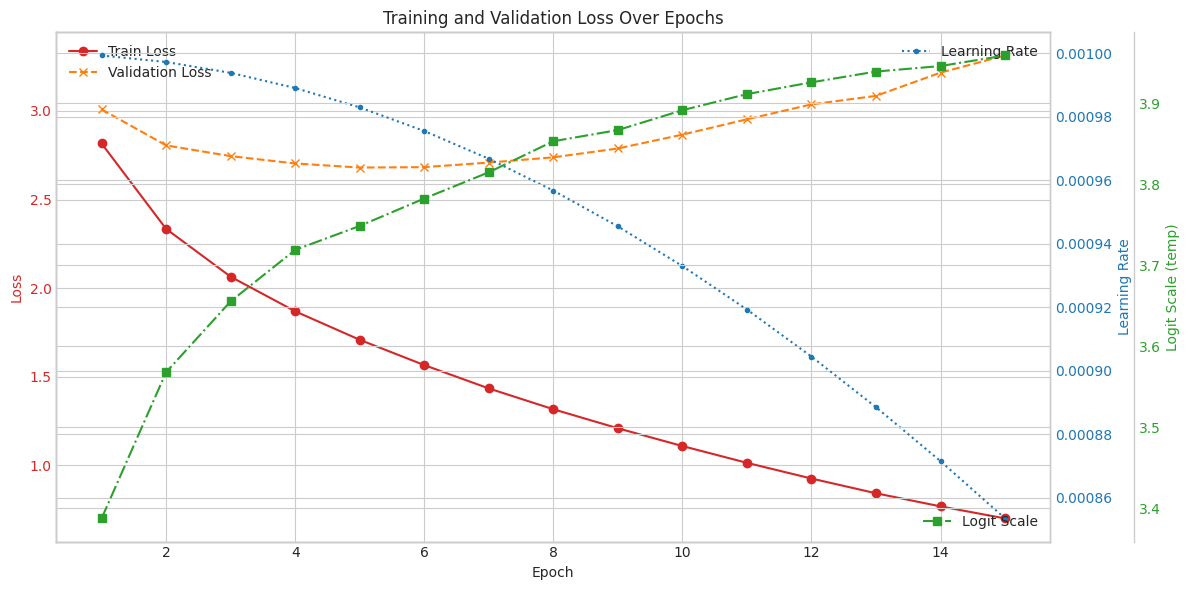

In [11]:
plot_training_log("/workspace/python-dlshogi2/shogi_clip_results/training_log_20250605_181837.csv")

In [ ]:
config = ConfigTrain()
main_train(config)

In [10]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import logging

# --- ShogiClipModel, ShogiClipDataset, shogi_clip_collate_fn は定義済みとします ---
# from your_modules import ShogiClipModel, ShogiClipDataset, shogi_clip_collate_fn

# ロガー設定
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

def extract_all_embeddings(model, dataloader, device):
    """
    データローダから全ての局面埋め込みとテキスト埋め込みを抽出します。
    データセット内のi番目の局面がi番目のテキストとペアであると仮定します。
    """
    model.eval() # モデルを評価モードに設定
    all_board_embeddings_list = []
    all_text_embeddings_list = []

    with torch.no_grad(): # 勾配計算を無効化
        for batch_f1, batch_f2, batch_texts in tqdm(dataloader, desc="Embedding Extraction"):
            batch_f1 = batch_f1.to(device)
            batch_f2 = batch_f2.to(device)
            # batch_texts は文字列のリストなので、モデル内部で処理される

            board_embeds_norm, text_embeds_norm, _ = model(batch_f1, batch_f2, batch_texts)
            
            all_board_embeddings_list.append(board_embeds_norm.cpu())
            all_text_embeddings_list.append(text_embeds_norm.cpu())

    all_board_embeddings = torch.cat(all_board_embeddings_list, dim=0)
    all_text_embeddings = torch.cat(all_text_embeddings_list, dim=0)
    
    # データセット内のi番目の局面はi番目のテキストと対応すると仮定
    # ground_truth_indices[i] = i となる (クエリiの正解はデータベースのアイテムi)
    num_samples = all_board_embeddings.size(0)
    ground_truth_indices = torch.arange(num_samples, dtype=torch.long)
    
    logging.info(f"Extracted {num_samples} board embeddings, shape: {all_board_embeddings.shape}")
    logging.info(f"Extracted {num_samples} text embeddings, shape: {all_text_embeddings.shape}")
    
    return all_board_embeddings, all_text_embeddings, ground_truth_indices

def calculate_recall_at_k(query_embeddings, database_embeddings, 
                          ground_truth_indices_for_queries, k_values, 
                          similarity_batch_size=512, device='cpu'):
    """
    Recall@K を計算します。

    Args:
        query_embeddings (torch.Tensor): クエリ埋め込み (N_queries, D_embed)
        database_embeddings (torch.Tensor): データベース埋め込み (N_database, D_embed)
        ground_truth_indices_for_queries (torch.Tensor): 各クエリに対する正解のインデックス (N_queries,)
                                                        (database_embeddings 内でのインデックス)
        k_values (list of int): 計算するKの値のリスト (例: [1, 5, 10])
        similarity_batch_size (int): 類似度計算時のバッチサイズ (メモリ節約のため)
        device (str): 計算に使用するデバイス ('cuda' or 'cpu')

    Returns:
        dict: Kをキー、Recall@Kの値を値とする辞書
    """
    num_queries = query_embeddings.size(0)
    # num_database_items = database_embeddings.size(0) # 未使用だが情報として

    recalls = {k: 0.0 for k in k_values}
    max_k = max(k_values)

    query_embeddings = query_embeddings.to(device)
    database_embeddings = database_embeddings.to(device)
    ground_truth_indices_for_queries = ground_truth_indices_for_queries.to(device)


    for i in range(0, num_queries, similarity_batch_size):
        batch_query_embeds = query_embeddings[i : i + similarity_batch_size]
        batch_gt_indices = ground_truth_indices_for_queries[i : i + similarity_batch_size]
        
        # コサイン類似度を計算 (埋め込みは正規化済みと仮定)
        # (current_batch_size, D_embed) @ (D_embed, N_database) -> (current_batch_size, N_database)
        similarity_matrix = batch_query_embeds @ database_embeddings.t()
        
        # 各クエリについて類似度が高い順にデータベースのインデックスを取得
        _, top_k_indices_matrix = torch.topk(similarity_matrix, k=max_k, dim=1, largest=True, sorted=True)
        
        # 各KについてRecallを計算
        for k_val in k_values:
            # 現在のKまでのトップインデックスを取得
            current_top_k_indices = top_k_indices_matrix[:, :k_val] # (current_batch_size, k_val)
            
            # 正解インデックスがトップKに含まれているかを確認
            # batch_gt_indices.unsqueeze(1) -> (current_batch_size, 1)
            # 比較 (current_batch_size, 1) == (current_batch_size, k_val) -> (current_batch_size, k_val) (boolean)
            # .any(dim=1) -> (current_batch_size,) (boolean)
            correct_at_k = (batch_gt_indices.unsqueeze(1) == current_top_k_indices).any(dim=1)
            recalls[k_val] += correct_at_k.sum().item()

    # Recall@Kを計算 (成功数 / 総クエリ数)
    for k_val in k_values:
        recalls[k_val] /= num_queries
        
    return recalls

def calculate_precision_at_k(
    query_embeddings, 
    database_embeddings, 
    ground_truth_indices_for_queries, # 各クエリの正解アイテムのインデックス
    k_values, 
    similarity_batch_size=512, 
    device='cpu'
):
    num_queries = query_embeddings.size(0)
    precisions = {k: 0.0 for k in k_values}

    query_embeddings = query_embeddings.to(device)
    database_embeddings = database_embeddings.to(device)
    ground_truth_indices_for_queries = ground_truth_indices_for_queries.to(device)

    for i in range(0, num_queries, similarity_batch_size):
        batch_query_embeds = query_embeddings[i : i + similarity_batch_size]
        batch_gt_indices = ground_truth_indices_for_queries[i : i + similarity_batch_size]

        similarity_matrix = batch_query_embeds @ database_embeddings.t()

        # 各KについてPrecisionを計算
        for k_val in k_values:
            # 類似度が高い順にトップKのインデックスを取得
            _, current_top_k_indices = torch.topk(similarity_matrix, k=k_val, dim=1, largest=True, sorted=True)

            # 上位K件に正解が含まれているか (Recall@Kの時と同じ)
            # (current_batch_size, 1) == (current_batch_size, k_val) -> (current_batch_size, k_val)
            # .sum(dim=1) で、各クエリの上位K件に含まれる正解の数をカウント
            num_correct_in_top_k = (batch_gt_indices.unsqueeze(1) == current_top_k_indices).sum(dim=1).float()

            # Precision@K = (上位K件の正解数) / K
            batch_precision_at_k = num_correct_in_top_k / k_val
            precisions[k_val] += batch_precision_at_k.sum().item()

    for k_val in k_values:
        precisions[k_val] /= num_queries # 全クエリで平均

    return precisions

def evaluate_retrieval_with_precision(model, eval_dataloader, device, k_values=[1, 5, 10]):
    logging.info("Starting retrieval evaluation (Recall & Precision)...")

    all_board_embeddings, all_text_embeddings, gt_indices = extract_all_embeddings(model, eval_dataloader, device)

    if all_board_embeddings.nelement() == 0 or all_text_embeddings.nelement() == 0:
        logging.error("Embeddings could not be extracted. Skipping evaluation.")
        return None, None, None, None

    # Board-to-Text
    logging.info("Calculating Board-to-Text Retrieval...")
    b2t_recalls = calculate_recall_at_k(all_board_embeddings, all_text_embeddings, gt_indices, k_values, device=device)
    b2t_precisions = calculate_precision_at_k(all_board_embeddings, all_text_embeddings, gt_indices, k_values, device=device)
    for k_val in k_values:
        logging.info(f"  Board-to-Text R@{k_val}: {b2t_recalls.get(k_val, 0.0):.4f}, P@{k_val}: {b2t_precisions.get(k_val, 0.0):.4f}")

    # Text-to-Board
    logging.info("Calculating Text-to-Board Retrieval...")
    t2b_recalls = calculate_recall_at_k(all_text_embeddings, all_board_embeddings, gt_indices, k_values, device=device)
    t2b_precisions = calculate_precision_at_k(all_text_embeddings, all_board_embeddings, gt_indices, k_values, device=device)
    for k_val in k_values:
        logging.info(f"  Text-to-Board R@{k_val}: {t2b_recalls.get(k_val, 0.0):.4f}, P@{k_val}: {t2b_precisions.get(k_val, 0.0):.4f}")

    return b2t_recalls, b2t_precisions, t2b_recalls, t2b_precisions

In [11]:
# --- 設定 (configオブジェクトや変数から読み込む) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
projection_dim = 256 # ShogiClipModel が出力する埋め込み次元
batch_size_eval = 64 # 評価時のバッチサイズ
eval_hcpe_files = ["/workspace/test_202505.hcpe"]
eval_comment_csv_file = "/workspace/kif_caption/comments_202505_all.csv"
k_vals_for_recall = [1, 5, 10]

board_enc = dlshogiEncoder(projection_dim, arg_network="kifcaption", arg_model="/workspace/model/model_resnet10_swish-072_for_caption").to(device)
text_enc = BertTextEncoder(output_embedding_dim=projection_dim).to(device)
trained_shogi_clip_model = ShogiClipModel(board_enc, text_enc).to(device)

checkpoint_path = "/workspace/python-dlshogi2/shogi_clip_results/shogi_clip_model_best_20250605_181837.pth"
checkpoint = torch.load(checkpoint_path, map_location=device) # まず辞書全体をロード

# モデルのstate_dictを取り出してロードする
trained_shogi_clip_model.load_state_dict(checkpoint['model_state_dict'], strict=False) 


eval_dataset = ShogiClipDataset(hcpe_file_paths=eval_hcpe_files, comment_csv_file_path=eval_comment_csv_file) # 評価用データセット
eval_loader = DataLoader(eval_dataset, batch_size=batch_size_eval, 
                            shuffle=False, collate_fn=shogi_clip_collate_fn) # 必ず shuffle=False

# --- 評価の実行 ---
b2t_recalls, b2t_precisions, t2b_recalls, t2b_precisions = evaluate_retrieval_with_precision(trained_shogi_clip_model, eval_loader, device, k_vals_for_recall)

print("\n--- Final Recall@K Results ---")
if b2t_recalls:
    print("Board-to-Text:", b2t_recalls)
if t2b_recalls:
    print("Text-to-Board:", t2b_recalls)

print("\n--- Final precision@K Results ---")
if b2t_precisions:
    print("Board-to-Text:", b2t_precisions)
if t2b_precisions:
    print("Text-to-Board:", t2b_precisions)

Some weights of the model checkpoint at cl-tohoku/bert-base-japanese-whole-word-masking were not used when initializing BertModel: ['cls.predictions.transform.dense.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
2025-06-06 02:35:00,277 - INFO - ShogiClipModel initialized.
2025-06-06 02:35:00,714 - INFO - HCPEデータをロード中: /workspace/test_2


--- Final Recall@K Results ---
Board-to-Text: {1: 0.02820825352603169, 5: 0.0743223634569621, 10: 0.10731905508154856}
Text-to-Board: {1: 0.01913924197573858, 5: 0.0594491845144814, 10: 0.09090777178013813}

--- Final precision@K Results ---
Board-to-Text: {1: 0.02822276394451216, 5: 0.014864472969540509, 10: 0.010731905735101556}
Text-to-Board: {1: 0.01925532532358233, 5: 0.011892739140888453, 10: 0.009090777354451036}
